# Détection de SMS indésirables avec le deep learning

## Contexte

AT&T cherche à réduire l'exposition de ses utilisateurs aux SMS indésirables.  
L'objectif de ce projet est de construire un classifieur binaire capable de prédire, à partir du seul contenu textuel d'un message, s'il s'agit d'un **ham** (message normal) ou d'un **spam** (message indésirable).

## Objectif pédagogique

Le brief demande :
- un notebook qui exécute le **préprocessing** ;
- l'entraînement de **un ou plusieurs modèles de deep learning** ;
- une **présentation claire des performances**.

Le parti pris retenu ici reste volontairement simple et défendable :
1. préparation minimale mais rigoureuse des données ;
2. un modèle principal simple, rapide et lisible ;
3. un modèle LSTM comme benchmark plus séquentiel ;
4. une comparaison finale fondée sur des métriques adaptées à un dataset déséquilibré.

## 1. Import des bibliothèques

Nous utilisons :
- **pandas** et **numpy** pour manipuler les données ;
- **matplotlib** pour les visualisations ;
- **scikit-learn** pour le découpage train/test et les métriques ;
- **TensorFlow / Keras** pour les modèles de deep learning.

Les logs TensorFlow sont volontairement réduits afin de garder un notebook lisible.

In [1]:
import os
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

keras.utils.set_random_seed(42)

## 2. Chargement des données

Le jeu de données fourni contient des SMS annotés en deux classes :
- **ham** : message normal ;
- **spam** : message indésirable.

Le fichier d'origine comporte des colonnes supplémentaires vides. Nous conservons uniquement les colonnes utiles au problème :
- `label` : la classe (`ham` ou `spam`) ;
- `text` : le contenu du SMS.

In [2]:
data_path = Path("data/spam.csv")
if not data_path.exists():
    data_path = Path("../data/spam.csv")

df = pd.read_csv(data_path, encoding="latin1")
df = df[["v1", "v2"]].copy()
df.columns = ["label", "text"]

df.head()

,label,text,label_num
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives around here though",0


In [3]:
print("Taille du dataset :", df.shape)
print("Valeurs manquantes :")
print(df.isna().sum())

Taille du dataset : (5572, 3)
Valeurs manquantes :
label    0
text     0
dtype: int64


## 3. Première lecture du dataset

Avant de modéliser, il faut comprendre la structure des données.  
Ici, le dataset contient **5 572 SMS**. La première vérification importante concerne l'équilibre des classes, car il influence directement le choix des métriques.

Sur un problème déséquilibré, l'accuracy seule peut être trompeuse.  
Nous suivrons donc en priorité :
- la **precision** ;
- le **recall** ;
- le **F1-score**.

In [4]:
class_counts = df["label"].value_counts()
class_percentages = (df["label"].value_counts(normalize=True) * 100).round(2)

summary_df = pd.DataFrame({
    "Nombre de messages": class_counts,
    "Pourcentage (%)": class_percentages
})

summary_df

,Nombre de messages,Pourcentage (%)
label,,
ham,4825,86.59
spam,747,13.41


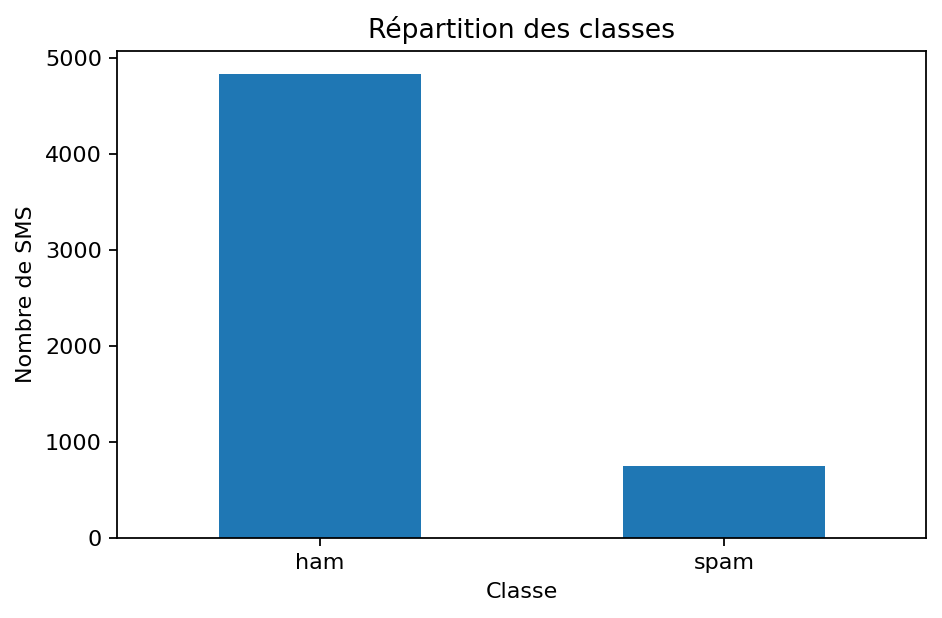

In [5]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre de SMS")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Lecture métier

Le dataset est clairement déséquilibré : les messages **ham** sont très majoritaires.  
Dans un contexte réel, cela signifie qu'un modèle peut sembler performant en prédisant trop souvent la classe majoritaire.  
L'enjeu métier est donc double :

- **limiter les faux positifs**, pour éviter de bloquer des messages légitimes ;
- **limiter les faux négatifs**, pour ne pas laisser passer trop de spams.

Le compromis entre precision et recall est donc central.

## 4. Préparation des données pour le deep learning

Nous transformons d'abord la cible textuelle en cible numérique :
- `ham -> 0`
- `spam -> 1`

Ensuite :
1. séparation en variables explicatives (`X`) et cible (`y`) ;
2. découpage en **train** et **test** avec conservation de la proportion des classes ;
3. tokenization du texte ;
4. padding afin d'obtenir des séquences de longueur homogène.

In [6]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

X = df["text"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test  :", y_test.shape)

Taille X_train : (4457,)
Taille X_test  : (1115,)
Taille y_train : (4457,)
Taille y_test  : (1115,)


In [7]:
max_words = 5000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("Shape X_train_pad :", X_train_pad.shape)
print("Shape X_test_pad  :", X_test_pad.shape)

Shape X_train_pad : (4457, 50)
Shape X_test_pad  : (1115, 50)


### Choix de préparation

Le préprocessing reste volontairement simple :
- pas de nettoyage agressif ;
- pas de stemming ou lemmatization ;
- pas d'ingénierie de variables manuelle.

Ce choix est cohérent avec le brief : l'objectif est d'évaluer ce que des architectures de deep learning peuvent apprendre directement à partir du texte, après transformation en séquences numériques.

## 5. Fonctions utilitaires

Pour garder le notebook lisible, nous regroupons dans cette section :
- la construction des modèles ;
- l'entraînement avec **EarlyStopping** ;
- l'évaluation standardisée ;
- l'affichage des courbes d'apprentissage.

In [8]:
def build_average_model(max_words, max_len):
    keras.utils.set_random_seed(42)
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=max_words, output_dim=32),
        GlobalAveragePooling1D(),
        Dense(16, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )
    return model


def build_lstm_model(max_words, max_len):
    keras.utils.set_random_seed(42)
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=max_words, output_dim=32),
        LSTM(32),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )
    return model


def train_model(model, X_train_pad, y_train, epochs=10, batch_size=32):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )
    history = model.fit(
        X_train_pad,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0,
    )
    return history


def evaluate_model(model, X_test_pad, y_test):
    y_pred_proba = model.predict(X_test_pad, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype("int32")

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }
    return y_pred, y_pred_proba, metrics


def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df.index + 1, history_df["loss"], label="train")
    axes[0].plot(history_df.index + 1, history_df["val_loss"], label="validation")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df.index + 1, history_df["accuracy"], label="train")
    axes[1].plot(history_df.index + 1, history_df["val_accuracy"], label="validation")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 6. Modèle 1 - Embedding + GlobalAveragePooling1D

Le premier modèle suit le conseil central du brief : **start simple**.

Architecture :
1. **Embedding** : projection des mots dans un espace dense ;
2. **GlobalAveragePooling1D** : agrégation simple de la séquence ;
3. **Dense + Dropout** : extraction non linéaire et régularisation ;
4. **Dense(sigmoid)** : sortie binaire.

Ce modèle sert de base principale du projet.

In [9]:
average_model = build_average_model(max_words=max_words, max_len=max_len)
history_average = train_model(average_model, X_train_pad, y_train, epochs=10, batch_size=32)

pd.DataFrame(history_average.history).round(4)

,accuracy,loss,val_accuracy,val_loss
0,0.8662,0.4008,0.8430,0.3666
1,0.8715,0.3278,0.8430,0.3430
2,0.8715,0.2943,0.8430,0.2897
3,0.8875,0.2281,0.9126,0.2093
4,0.9419,0.1606,0.9552,0.1499
5,0.9663,0.1210,0.9652,0.1126
6,0.9776,0.0975,0.9720,0.0896
7,0.9820,0.0771,0.9765,0.0731
8,0.9860,0.0614,0.9798,0.0632
9,0.9854,0.0543,0.9821,0.0570


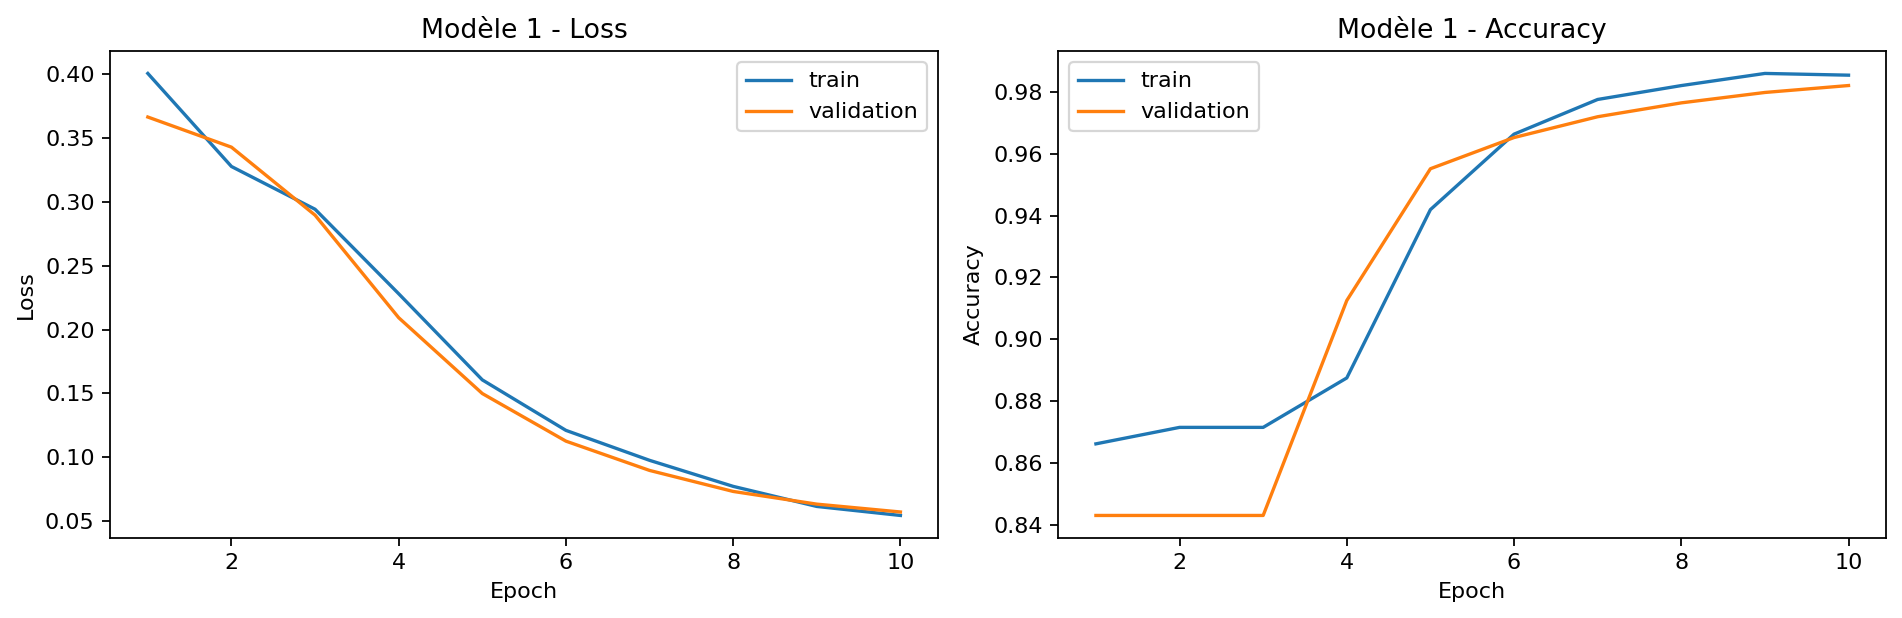

In [10]:
plot_history(history_average, "Modèle 1")

In [11]:
y_pred_average, y_pred_proba_average, metrics_average = evaluate_model(
    average_model,
    X_test_pad,
    y_test,
)

pd.DataFrame([metrics_average]).round(4)

,Accuracy,Precision,Recall,F1-score
0,0.9785,0.9562,0.8792,0.9161


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



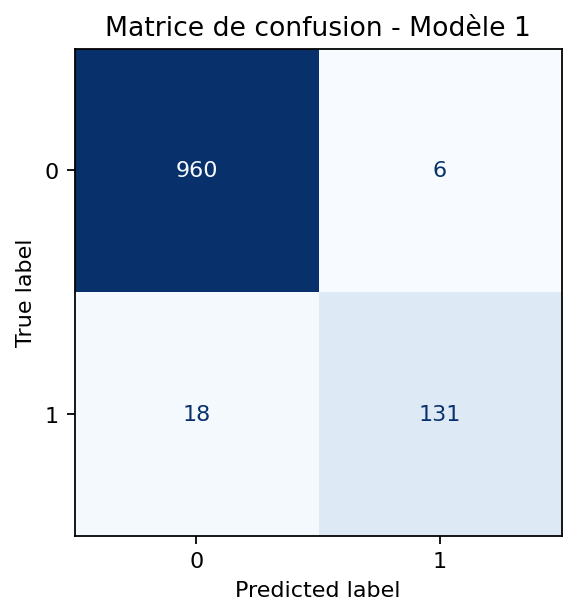

In [12]:
print(classification_report(y_test, y_pred_average))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_average)).plot(cmap="Blues")
plt.title("Matrice de confusion - Modèle 1")
plt.show()

### Lecture des résultats du modèle 1

Le premier modèle atteint un niveau de performance élevé tout en restant simple.  
C'est un bon signal pédagogique : sur un dataset de SMS court et relativement standardisé, une architecture compacte peut déjà capturer une grande partie de l'information utile.

Ce modèle est également attractif d'un point de vue opérationnel :
- il est rapide à entraîner ;
- il est plus léger qu'un LSTM ;
- il constitue une base robuste pour une première mise en production.

## 7. Modèle 2 - Embedding + LSTM

Le deuxième modèle introduit une couche **LSTM** afin de mieux prendre en compte l'ordre des mots dans la séquence.

Cette architecture est plus expressive, mais aussi :
- plus coûteuse à entraîner ;
- plus sensible au volume de données ;
- pas nécessairement meilleure sur des messages très courts.

L'objectif ici est donc moins de chercher la complexité que de vérifier si une modélisation séquentielle apporte un gain réel.

In [13]:
lstm_model = build_lstm_model(max_words=max_words, max_len=max_len)
history_lstm = train_model(lstm_model, X_train_pad, y_train, epochs=10, batch_size=32)

pd.DataFrame(history_lstm.history).round(4)

,accuracy,loss,val_accuracy,val_loss
0,0.8648,0.4245,0.8430,0.4409
1,0.8715,0.3859,0.8430,0.4125
2,0.9621,0.1478,0.9529,0.2007
3,0.9734,0.1262,0.9664,0.1458
4,0.9773,0.1021,0.9686,0.1513
5,0.9784,0.1087,0.9709,0.1322
6,0.9843,0.0820,0.9709,0.1505
7,0.9818,0.0916,0.9675,0.1423


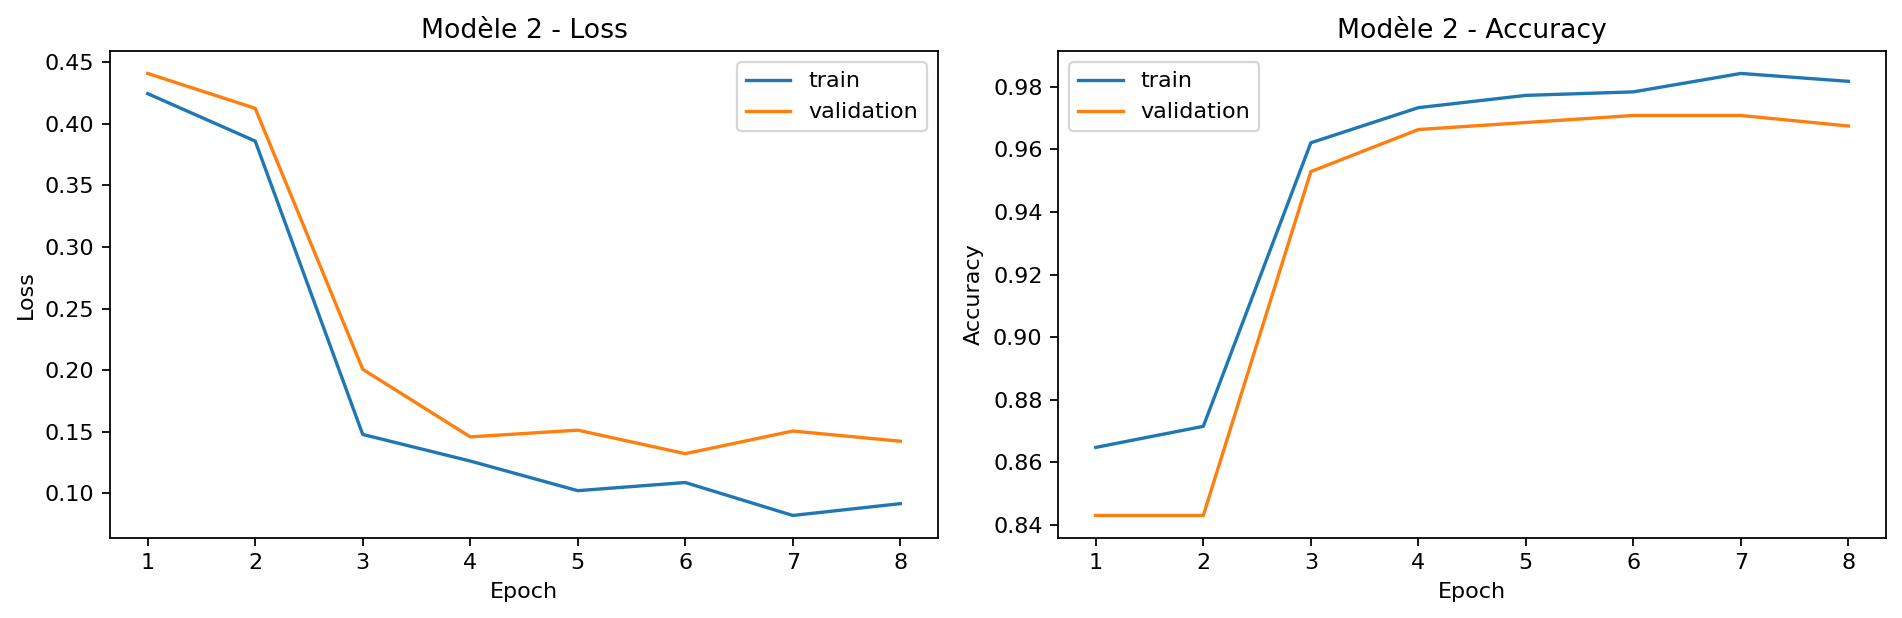

In [14]:
plot_history(history_lstm, "Modèle 2")

In [15]:
y_pred_lstm, y_pred_proba_lstm, metrics_lstm = evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
)

pd.DataFrame([metrics_lstm]).round(4)

,Accuracy,Precision,Recall,F1-score
0,0.9632,0.9286,0.7852,0.8509


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       966
           1       0.93      0.79      0.85       149

    accuracy                           0.96      1115
   macro avg       0.95      0.89      0.91      1115
weighted avg       0.96      0.96      0.96      1115



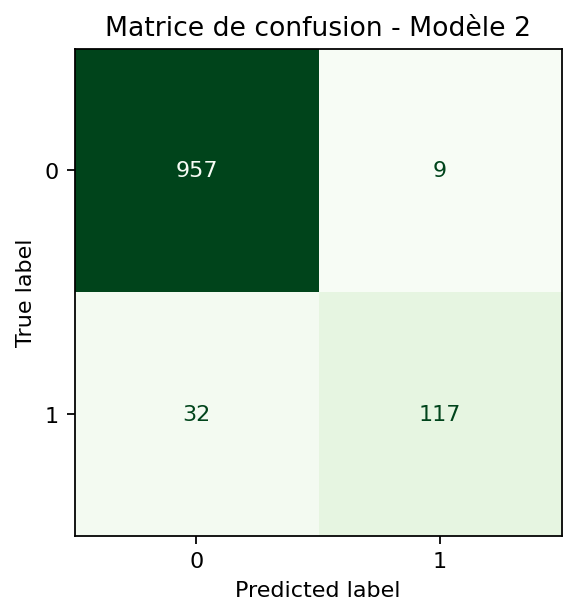

In [16]:
print(classification_report(y_test, y_pred_lstm))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lstm)).plot(cmap="Greens")
plt.title("Matrice de confusion - Modèle 2")
plt.show()

## 8. Comparaison des modèles

Nous comparons maintenant les deux architectures sur les mêmes données et avec les mêmes métriques.  
Cette comparaison est essentielle : elle permet de retenir le meilleur compromis entre performance, simplicité et coût de calcul.

In [17]:
comparison_df = pd.DataFrame([
    {"Modèle": "Embedding + GlobalAveragePooling1D", **metrics_average},
    {"Modèle": "Embedding + LSTM", **metrics_lstm},
]).round(4)

comparison_df

,Modèle,Accuracy,Precision,Recall,F1-score
0,Embedding + GlobalAveragePooling1D,0.9785,0.9562,0.8792,0.9161
1,Embedding + LSTM,0.9632,0.9286,0.7852,0.8509


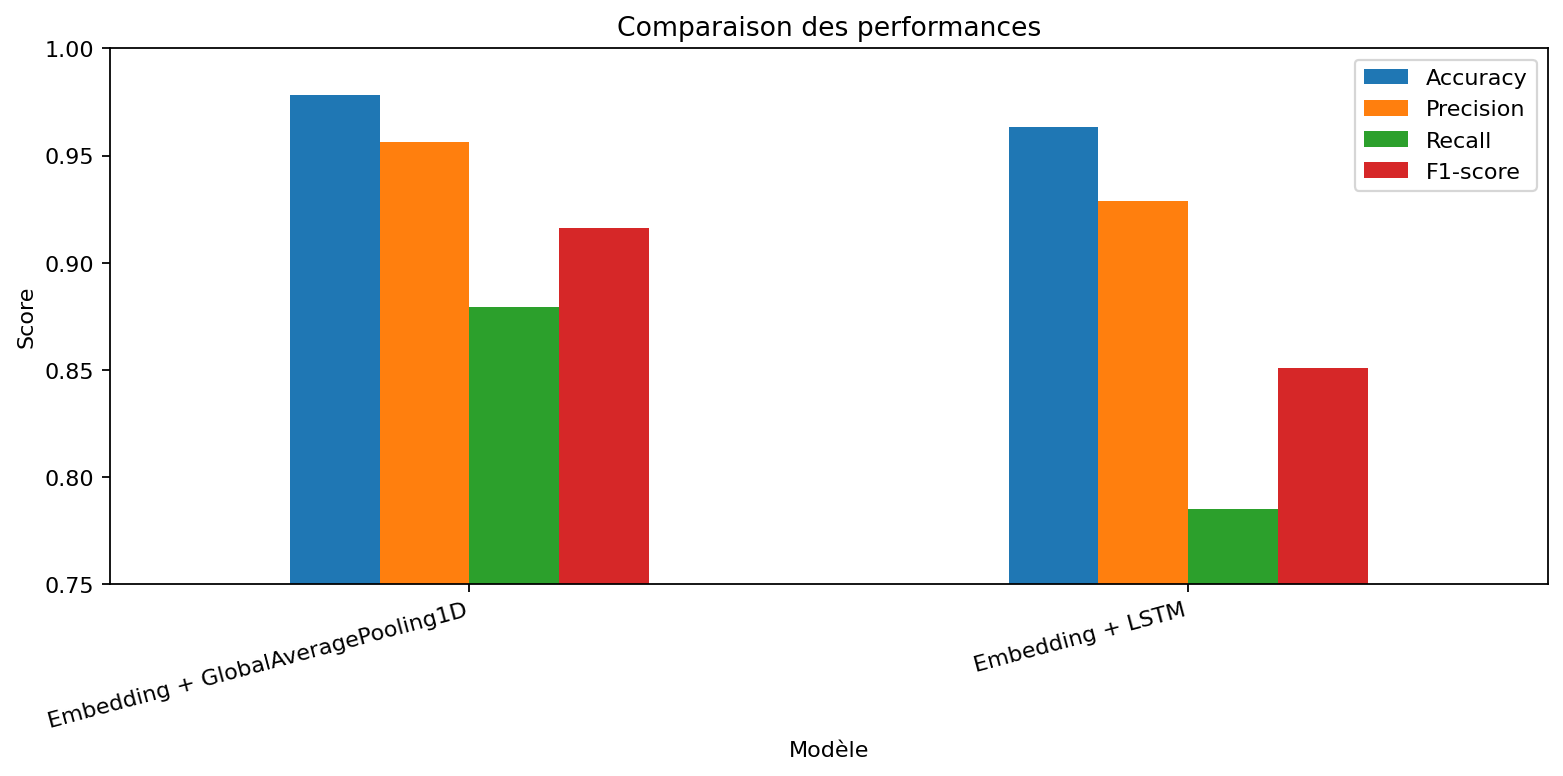

In [18]:
comparison_plot = comparison_df.set_index("Modèle")[["Accuracy", "Precision", "Recall", "F1-score"]]
comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparaison des performances")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.ylim(0.75, 1.0)
plt.tight_layout()
plt.show()

### Interprétation

Dans cette version du projet, le modèle **Embedding + GlobalAveragePooling1D** est retenu comme modèle principal.

Ce résultat est cohérent :
- les SMS sont courts ;
- le signal lexical est fort ;
- la simplicité du modèle limite le risque de surapprentissage ;
- le gain potentiel d'un LSTM ne compense pas ici son coût supplémentaire.

Autrement dit, un modèle plus complexe n'est pas automatiquement meilleur.  
Le bon choix est celui qui reste le plus robuste et le plus justifiable au regard du jeu de données.

## 9. Limites du projet

Le projet reste volontairement sobre et aligné avec le brief, mais plusieurs limites doivent être reconnues :

1. **Taille du dataset** : 5 572 messages restent modestes pour du deep learning.
2. **Données textuelles seules** : aucun signal additionnel n'est utilisé (numéro émetteur, fréquence, métadonnées, langue, etc.).
3. **Messages courts** : les architectures complexes ont moins d'espace pour exploiter des dépendances longues.
4. **Évaluation hors production** : les résultats sont mesurés sur un split statique et non sur un flux réel de messages.

Ces limites n'invalident pas le projet, mais elles bornent ce que l'on peut conclure.

## 10. Pistes d'amélioration

Plusieurs prolongements sont cohérents avec le cours et avec le brief :

- tester un **transfer learning** textuel si le cadre pédagogique l'autorise ;
- comparer avec des embeddings pré-entraînés ;
- ajuster les seuils de décision selon le coût métier des faux positifs et faux négatifs ;
- enrichir le problème avec des variables contextuelles ;
- mettre en place un suivi plus robuste des expérimentations et des performances dans le temps.

Le point important est de n'ajouter de la complexité que si elle apporte une valeur démontrée.

## 11. Conclusion

Le projet répond au besoin formulé dans le brief : construire un détecteur de spam fondé sur le contenu textuel des SMS.

La démarche retenue est volontairement simple, rigoureuse et progressive :
- préparation des données ;
- transformation du texte en séquences ;
- entraînement de deux architectures ;
- comparaison sur des métriques adaptées au déséquilibre des classes.

Le principal enseignement est clair : sur ce dataset, un modèle simple **Embedding + GlobalAveragePooling1D** fournit le meilleur compromis entre performance, lisibilité et coût de calcul.  
Ce résultat est techniquement défendable et pédagogiquement cohérent avec la consigne de départ.